In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))


from query_helper import get_connection, run_query

conn = get_connection()

Connection to database successful.


In [2]:
"""
All imports needed for EDA
"""
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
"""
Load data into Python for analysis. Combine them.
"""

df = run_query(conn, """
SELECT DISTINCT 
    patients.patient_id,
    patients.age,
    patients.gender,
    patients.city,
    patients.insurance_provider,
    patients.chronic_flag,
    patients.registration_date,

    visits.visit_id,
    visits.visit_date,
    visits.department,
    visits.visit_type,
    visits.length_of_stay_hours,
    visits.risk_score,
    visits.doctor_id,
    
    billing.bill_id,
    billing.billed_amount,
    billing.approved_amount,
    billing.claim_status,
    billing.payment_days,
    billing.billing_date

FROM
    patients
        INNER JOIN visits on (patients.patient_id = visits.patient_id)
        INNER JOIN billing on (visits.visit_id = billing.visit_id)
""", title="Load Combined Dataset"
)


  Load Combined Dataset

📋 Query Plan:
   SCAN billing USING INDEX idx_billing_date
   SEARCH visits USING INTEGER PRIMARY KEY (rowid=?)
   SEARCH patients USING INTEGER PRIMARY KEY (rowid=?)



📊 Results (25000 rows):


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,2964,25,F,Chennai,HealthPlus,1,2025-07-04,3,2025-07-13,ICU,ER,34.36,Low,153,3,5038.97,5038.97,Paid,NaN,2025-01-20
1,4271,42,F,Mumbai,MediCareX,1,2025-10-31,669,2026-01-17,Neurology,ICU,12.74,Medium,138,669,21706.39,NaN,Paid,5.0,2025-01-20
2,1826,52,M,Pune,CareOne,1,2025-01-23,1264,2025-10-01,General,ICU,24.16,Low,123,1264,25918.41,25918.41,Paid,15.0,2025-01-20
3,1224,52,M,Delhi,CareOne,1,2025-06-23,1326,2025-11-05,General,OPD,7.43,Low,134,1326,21173.56,0.00,Rejected,14.0,2025-01-20
4,1318,39,M,Chennai,HealthPlus,1,2025-11-13,1455,2025-08-20,Cardiology,ER,17.72,High,136,1455,8649.89,8649.89,Paid,17.0,2025-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,4156,41,M,Bangalore,SecureLife,1,2025-06-23,22496,2025-10-11,Neurology,ICU,8.68,Medium,186,22496,21664.08,0.00,Rejected,19.0,2026-01-20
24996,2166,26,M,Mumbai,HealthPlus,0,2025-05-14,24269,2025-05-20,General,ER,22.60,Low,180,24269,1758.34,1758.34,Paid,15.0,2026-01-20
24997,203,64,F,Pune,HealthPlus,1,2025-06-16,24461,2025-08-10,Orthopedics,ICU,36.48,Low,115,24461,1896.25,1896.25,Paid,16.0,2026-01-20
24998,1802,43,M,Delhi,CareOne,1,2025-04-14,24558,2025-09-27,ER,ICU,15.24,Low,141,24558,19183.31,9923.84,Pending,27.0,2026-01-20


In [4]:
"""
Analyze missing values in approved_amount, payment_days, and length_of_stay_hours.
"""

cols = ["approved_amount", "payment_days", "length_of_stay_hours"]

# Count and percentage of missing values
missing = df[cols].isnull().sum().rename("missing_count").to_frame()
missing["total"] = len(df)
missing["missing_pct"] = (missing["missing_count"] / missing["total"] * 100).round(2)
display(missing)

# Breakdown: are missing values concentrated in specific groups
for col in cols:
    if df[col].isnull().any():
        print(f"\n{'='*60}")
        print(f"  Missing '{col}' by department & claim_status")
        print(f"{'='*60}")
        breakdown = (
            df[df[col].isnull()]
            .groupby(["department", "claim_status"])
            .size()
            .reset_index(name="missing_count")
            .sort_values("missing_count", ascending=False)
        )
        display(breakdown)

,missing_count,total,missing_pct
approved_amount,1318,25000,5.27
payment_days,790,25000,3.16
length_of_stay_hours,0,25000,0.00



  Missing 'approved_amount' by department & claim_status


,department,claim_status,missing_count
3,ER,Paid,140
15,Orthopedics,Paid,138
6,General,Paid,137
12,Neurology,Paid,137
0,Cardiology,Paid,136
9,ICU,Paid,129
4,ER,Pending,57
1,Cardiology,Pending,52
7,General,Pending,51
10,ICU,Pending,50



  Missing 'payment_days' by department & claim_status


,department,claim_status,missing_count
0,Cardiology,Paid,95
6,General,Paid,86
12,Neurology,Paid,84
15,Orthopedics,Paid,67
9,ICU,Paid,67
3,ER,Paid,60
1,Cardiology,Pending,44
4,ER,Pending,40
16,Orthopedics,Pending,40
10,ICU,Pending,32


In [5]:
"""
Fix missing values for approved_amount column.
Fallback order: patient median → department median → global median.
"""


df["approved_amount"] = pd.to_numeric(df["approved_amount"], errors="coerce")

# Per-patient median
patient_median = df.groupby("patient_id")["approved_amount"].transform("median")

# Per-department median
dept_median = df.groupby("department")["approved_amount"].transform("median")

# Global median
global_median = df["approved_amount"].median()

df["approved_amount"] = (
    df["approved_amount"]
    .fillna(patient_median)
    .fillna(dept_median)
    .fillna(global_median)
)

print(f"Remaining missing approved_amount: {df['approved_amount'].isnull().sum()}")

Remaining missing approved_amount: 0


In [6]:
"""
Fix missing values for payment_days column.
Fallback order: patient median → department median → global median.
"""
df["payment_days"] = pd.to_numeric(df["payment_days"], errors="coerce")

# Per-patient median
patient_median = df.groupby("patient_id")["payment_days"].transform("median")

# Per-department median
dept_median = df.groupby("department")["payment_days"].transform("median")

# Global median
global_median = df["payment_days"].median()

df["payment_days"] = (
    df["payment_days"]
    .fillna(patient_median)
    .fillna(dept_median)
    .fillna(global_median)
)

print(f"Remaining missing payment_days: {df['payment_days'].isnull().sum()}")

Remaining missing payment_days: 0


In [7]:
"""
Fix missing values for length_of_stay_hours column.
Fallback order: patient median → department median → global median.
"""
df["length_of_stay_hours"] = pd.to_numeric(df["length_of_stay_hours"], errors="coerce")
# Per-patient median
patient_median = df.groupby("patient_id")["length_of_stay_hours"].transform("median")
# Per-department median
dept_median = df.groupby("department")["length_of_stay_hours"].transform("median")
# Global median
global_median = df["length_of_stay_hours"].median()
df["length_of_stay_hours"] = (
    df["length_of_stay_hours"]
    .fillna(patient_median)
    .fillna(dept_median)
    .fillna(global_median)
)
print(f"Remaining missing length_of_stay_hours: {df['length_of_stay_hours'].isnull().sum()}")

Remaining missing length_of_stay_hours: 0


In [8]:
"""
Print summary statistics for the cleaned columns.
"""

cols = ["approved_amount", "payment_days", "length_of_stay_hours"]

# Count and percentage of missing values
missing = df[cols].isnull().sum().rename("missing_count").to_frame()
missing["total"] = len(df)
missing["missing_pct"] = (missing["missing_count"] / missing["total"] * 100).round(2)
display(missing)

,missing_count,total,missing_pct
approved_amount,0,25000,0.0
payment_days,0,25000,0.0
length_of_stay_hours,0,25000,0.0


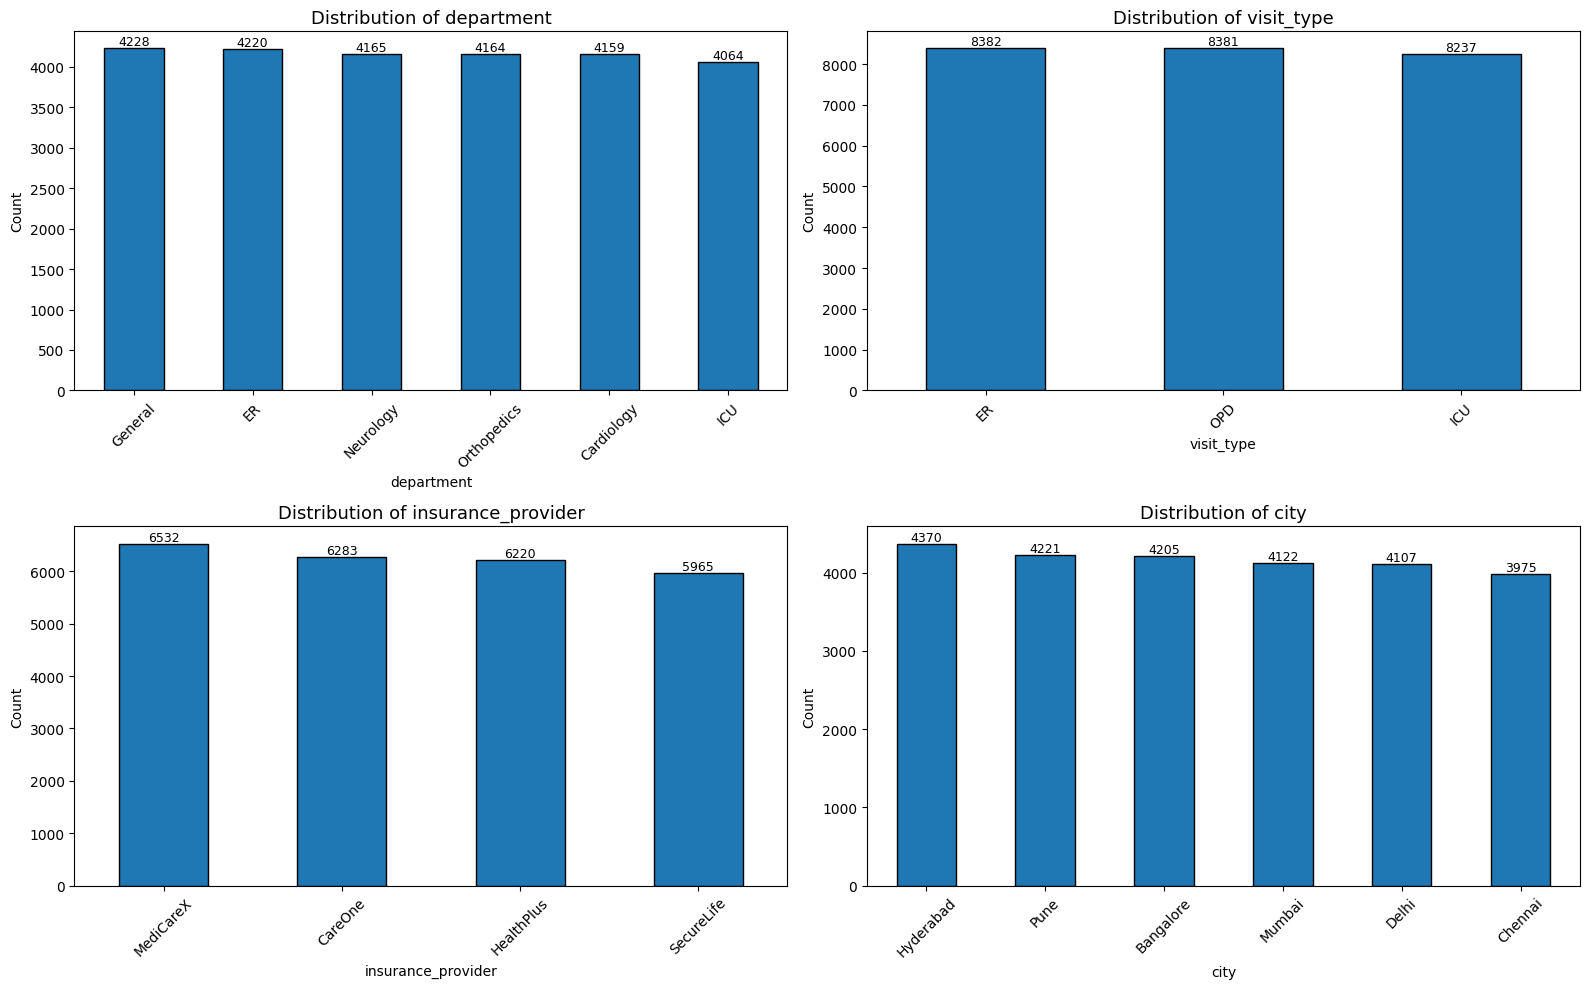


  Numeric summary grouped by 'department'


billed_amount                     approved_amount            \
                     mean    median       std            mean    median   
department                                                                
Cardiology       20695.18  19582.89  12404.78        16041.99  14047.26   
ER               21015.87  19686.06  12669.38        16383.82  14629.48   
General          20608.20  19600.60  12492.02        16109.87  14227.30   
ICU              20855.75  19650.86  12463.45        16369.09  14461.38   
Neurology        20962.80  19609.85  12760.59        16308.74  14516.12   
Orthopedics      21088.25  19754.84  12839.03        16461.46  14618.56   

                      length_of_stay_hours               payment_days         \
                  std                 mean median    std         mean median   
department                                                                     
Cardiology   13367.78                19.60  18.01  12.60        12.92   12.0   
ER           13588.52                19.53  18.12  12.27        13.13   13.0   
General      13392.48                19.43  18.13  12.30        12.96   13.0   
ICU          13472.09                19.36  17.85  12.30        12.94   12.0   
Neurology    13609.47                19.72  18.63  12.18        13.03   12.0   
Orthopedics  13821.96                19.66  18.38  12.23        13.24   13.0   

                   
              std  
department         
Cardiology   7.12  
ER           7.27  
General      7.01  
ICU          7.12  
Neurology    7.21  
Orthopedics  7.25


  Numeric summary grouped by 'visit_type'


billed_amount                     approved_amount            \
                    mean    median       std            mean    median   
visit_type                                                               
ER              20866.52  19699.01  12561.81        16127.37  14288.78   
ICU             20770.36  19534.17  12583.20        16220.84  14362.41   
OPD             20973.67  19757.80  12673.87        16486.76  14534.89   

                     length_of_stay_hours               payment_days         \
                 std                 mean median    std         mean median   
visit_type                                                                    
ER          13569.30                19.41  18.08  12.40        12.99   12.0   
ICU         13469.91                19.53  18.24  12.11        13.12   13.0   
OPD         13585.69                19.71  18.28  12.42        13.00   13.0   

                  
             std  
visit_type        
ER          7.19  
ICU         7.16  
OPD         7.14


  Numeric summary grouped by 'insurance_provider'


billed_amount                     approved_amount  \
                            mean    median       std            mean   
insurance_provider                                                     
CareOne                 20803.44  19579.55  12652.09        16208.49   
HealthPlus              20929.38  19647.82  12489.16        16338.95   
MediCareX               20604.89  19422.75  12606.57        16076.41   
SecureLife              21171.67  19941.92  12675.19        16511.13   

                                       length_of_stay_hours                \
                      median       std                 mean median    std   
insurance_provider                                                          
CareOne             14108.64  13556.96                19.54  18.42  12.23   
HealthPlus          14599.02  13373.94                19.85  18.60  12.43   
MediCareX           14354.05  13517.98                19.28  17.84  12.25   
SecureLife          14662.16  13726.78                19.55  17.97  12.34   

                   payment_days               
                           mean median   std  
insurance_provider                            
CareOne                   13.01   12.0  7.16  
HealthPlus                13.06   13.0  7.16  
MediCareX                 12.98   12.0  7.16  
SecureLife                13.09   13.0  7.17


  Numeric summary grouped by 'city'


billed_amount                     approved_amount            \
                   mean    median       std            mean    median   
city                                                                    
Bangalore      21044.48  19718.10  12755.30        16328.54  14389.03   
Chennai        20778.88  19597.59  12560.50        16197.51  14364.75   
Delhi          20891.34  19558.40  12650.77        16398.56  14490.78   
Hyderabad      20846.17  19637.29  12570.46        16136.14  14176.64   
Mumbai         20962.58  19722.04  12605.56        16422.90  14642.40   
Pune           20699.97  19571.90  12498.36        16195.36  14355.29   

                    length_of_stay_hours               payment_days         \
                std                 mean median    std         mean median   
city                                                                         
Bangalore  13607.74                19.57  18.26  12.20        12.97   12.0   
Chennai    13485.34                19.58  18.34  12.22        12.94   13.0   
Delhi      13596.35                19.47  18.23  12.27        13.15   12.0   
Hyderabad  13581.82                19.78  18.46  12.33        12.99   13.0   
Mumbai     13530.82                19.30  17.89  12.40        13.04   13.0   
Pune       13454.10                19.59  18.03  12.45        13.12   13.0   

                 
            std  
city             
Bangalore  7.22  
Chennai    7.17  
Delhi      7.35  
Hyderabad  7.15  
Mumbai     6.98  
Pune       7.11


  Numeric summary grouped by 'risk_score'


billed_amount                     approved_amount            \
                    mean    median       std            mean    median   
risk_score                                                               
High            20702.15  19705.76  12484.61        16000.89  14140.96   
Low             20900.72  19631.70  12587.42        16361.32  14434.60   
Medium          20934.15  19634.69  12719.16        16327.65  14519.56   

                     length_of_stay_hours               payment_days         \
                 std                 mean median    std         mean median   
risk_score                                                                    
High        13420.43                19.76  18.22  12.83        12.99   13.0   
Low         13534.22                19.15  18.08  11.50        13.06   13.0   
Medium      13636.81                20.08  18.52  13.22        13.03   13.0   

                  
             std  
risk_score        
High        7.18  
Low         7.12  
Medium      7.22

In [9]:
"""
Perform distribution analysis by department, visit_type, insurance_provider, and city.
"""



cat_cols = ["department", "visit_type", "insurance_provider", "city", "risk_score"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    counts.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"Distribution of {col}", fontsize=13)
    ax.set_ylabel("Count")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)

    # Annotate bars
    for bar in ax.patches:
        ax.annotate(
            f"{int(bar.get_height())}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=9,
        )

plt.tight_layout()
plt.show()

# Summary statistics for numeric columns split by each categorical column
numeric_cols = ["billed_amount", "approved_amount", "length_of_stay_hours", "payment_days"]

# Ensure numeric types (SQLite NULLs can cause string dtype)
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for cat in cat_cols:
    print(f"\n{'='*60}")
    print(f"  Numeric summary grouped by '{cat}'")
    print(f"{'='*60}")
    summary = df.groupby(cat)[numeric_cols].agg(["mean", "median", "std"]).round(2)
    display(summary)

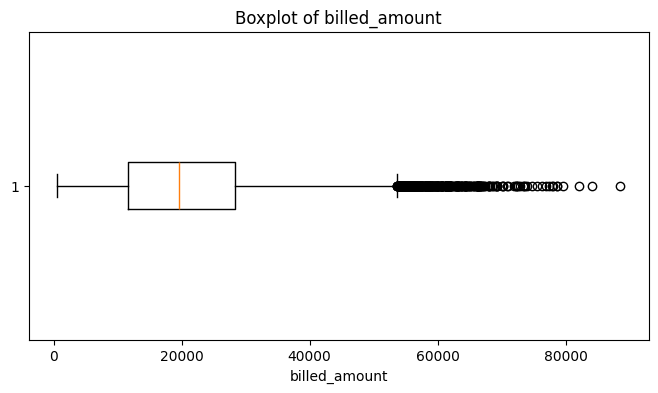


Outlier classification for billed_amount:


,count
billed_amount,
Normal,24627
Outlier,373


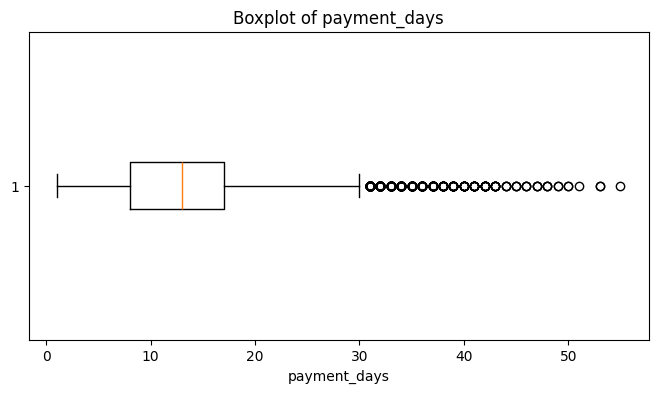


Outlier classification for payment_days:


,count
payment_days,
Normal,24489
Outlier,511


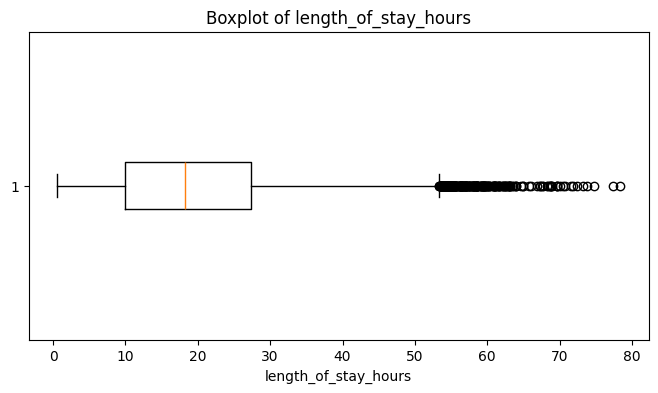


Outlier classification for length_of_stay_hours:


,count
length_of_stay_hours,
Normal,24744
Outlier,256



  Outlier Summary (Normal vs Outlier)


,normal,outlier,outlier_pct
column,,,
billed_amount,24627,373,1.49
payment_days,24489,511,2.04
length_of_stay_hours,24744,256,1.02


In [10]:
"""
Detect and classify outliers in billed_amount, payment_days, and length_of_stay_hours. 
"""
outlier_cols = ["billed_amount", "payment_days", "length_of_stay_hours"]
outlier_summary = []

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

    # Calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Classify outliers (local variable only — not added to df)
    outlier_flag = df[col].apply(lambda x: "Outlier" if x < lower_bound or x > upper_bound else "Normal")
    print(f"\nOutlier classification for {col}:")
    display(pd.DataFrame({"count": outlier_flag.value_counts()}))

    # Collect counts for summary table
    counts = outlier_flag.value_counts()
    outlier_summary.append({
        "column": col,
        "normal": counts.get("Normal", 0),
        "outlier": counts.get("Outlier", 0),
        "outlier_pct": round(counts.get("Outlier", 0) / len(df) * 100, 2),
    })

# Summary table: Normal vs Outlier per column
print(f"\n{'='*60}")
print("  Outlier Summary (Normal vs Outlier)")
print(f"{'='*60}")
outlier_summary_df = pd.DataFrame(outlier_summary).set_index("column")
display(outlier_summary_df)

In [11]:
df.to_csv(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "Database", "interim_eda.csv"), index=False)
print(f"Saved {len(df)} rows to Database/interim_eda.csv")

Saved 25000 rows to Database/interim_eda.csv
